# Loan Risk Classification — Grade A–G

**Structure:**
- `config.py` — paths, seed, device
- `data_processing.py` — feature engineering, ML & DL preprocessors
- `models.py` — FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py` — RF, KNN, SVM grid search wrappers

This notebook is the **control panel**: import modules, set hyperparameters,
launch training, evaluate.

## 0. Setup & Imports

In [1]:
import sys
import os

# Add src/ to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    feature_engineer,
    build_ml_preprocessor,
    prepare_ml_data,
    prepare_dl_data,
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    save_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    build_ft_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Exploration

In [ ]:
df = load_data(TRAIN_CSV)
df.head()

In [ ]:
df.info()

In [ ]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# PCA visualization
from sklearn.decomposition import PCA

X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

## 2. ML Models (Full-Data Cross-Validation)

The ML pipeline uses **all** the data with `GridSearchCV` (3-fold stratified CV).
Preprocessing is embedded inside the pipeline, so there is no data leakage.

In [ ]:
# Prepare ML data (loads, engineers, builds preprocessor)
X_ml, y_ml, col_lists, preprocessor, global_scaler, le_ml = prepare_ml_data(TRAIN_CSV)
print(f"\nML data ready: X={X_ml.shape}, y={y_ml.shape}")

### 2.1 Random Forest

In [ ]:
# Hyperparameters — edit here
rf_param_grid = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [None],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": ["sqrt", 0.3],
}

gs_rf = train_random_forest(X_ml, y_ml, preprocessor, param_grid=rf_param_grid)

In [ ]:
# Save & inspect (separate cell — re-run without retraining)
try:
    save_model(gs_rf.best_estimator_, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

In [ ]:
plot_rf_feature_importances(gs_rf, top_k=20)

### 2.2 KNN

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

knn_param_grid = {
    "pca__n_components": [30, 40, 50],
    "scaler__scaler_op": [StandardScaler()],
    "classifier__n_neighbors": [20, 30],
    "classifier__weights": ["distance"],
    "classifier__p": [2, 3],
}

gs_knn = train_knn(X_ml, y_ml, preprocessor, global_scaler, param_grid=knn_param_grid)

In [ ]:
try:
    save_model(gs_knn.best_estimator_, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

### 2.3 SVM

In [ ]:
svm_param_grid = {
    "scaler__scaler_op": [StandardScaler()],
    "classifier__C": [ 100, 300, 500],
    "classifier__kernel": ["rbf"],
    "classifier__gamma": ["scale"],
    "classifier__max_iter": [2000],
}

gs_svm = train_svm(X_ml, y_ml, preprocessor, global_scaler, param_grid=svm_param_grid)

In [ ]:
try:
    save_model(gs_svm.best_estimator_, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

## 3. Deep Learning Models (80/10/10 Split)

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [2]:
# Prepare DL data
#TODO: check if data are splitted in a balanced way
dl_data = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

print(f"\nDL data shapes:")
print(f"  X_train: {dl_data['X_train'].shape}")
print(f"  X_val  : {dl_data['X_val'].shape}")
print(f"  X_test : {dl_data['X_test'].shape}")
print(f"  Num cols: {dl_data['num_num_cols']}, Cat cols: {dl_data['num_cat_cols']}")
print(f"  Classes : {dl_data['num_classes']}")
print(f"  Cat cardinalities: {dl_data['cat_cardinalities']}")
print(f"  Feature names ({len(dl_data['feature_names'])}): {dl_data['feature_names'][:10]}...")

Loaded 148301 rows  (dropped 0 duplicates)
Dropped 37 cols with >80% missing
Dropped next_payment_date (not predictive feature)
Processed 4 'months_since_*' cols (added _ever flags, imputed -1)
Imputed 'missing' category in 19 categorical cols
Dropped 10 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:246: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:258: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering phase done: 126 features
  normal_dist      : 35
  safe_log_cols    : 71
  negative_cols    : 7
  ordinal_cols     : 0
  one_hot_cols     : 11
  target_encode_cols: 2
Dropped 37 cols with >80% missing
Dropped next_payment_date (not predictive feature)
Processed 4 'months_since_*' cols (added _ever flags, imputed -1)
Imputed 'missing' category in 19 categorical cols
Dropped 10 collinear cols
Feature engineering phase done: 126 features
  normal_dist      : 35
  safe_log_cols    : 71
  negative_cols    : 7
  ordinal_cols     : 0
  one_hot_cols     : 11
  target_encode_cols: 2
Dropped 37 cols with >80% missing
Dropped next_payment_date (not predictive feature)
Processed 4 'months_since_*' cols (added _ever flags, imputed -1)


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:246: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:258: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Imputed 'missing' category in 19 categorical cols
Dropped 9 collinear cols


/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:246: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["loan_contract_term_months"].fillna(mode_val, inplace=True)
/Users/ma3ti/Documents/Uni/Magistrale/Data_analytics/project/data_processing.py:258: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

Feature engineering phase done: 127 features
  normal_dist      : 37
  safe_log_cols    : 70
  negative_cols    : 7
  ordinal_cols     : 0
  one_hot_cols     : 11
  target_encode_cols: 2
Shifting 13 categorical columns by +1...

DL data shapes:
  X_train: (118639, 126)
  X_val  : (14831, 126)
  X_test : (14831, 126)
  Num cols: 113, Cat cols: 13
  Classes : 7
  Cat cardinalities: [6, 5, 4, 53, 4, 4, 4, 4, 4, 6, 880, 8, 15]
  Feature names (126): ['loan_contract_approved_amount', 'loan_contract_term_months', 'loan_contract_interest_rate', 'loan_payment_installments_count', 'borrower_profile_employment_length', 'borrower_income_annual', 'loan_status_current_code', 'borrower_dti_ratio', 'credit_delinquencies_2yrs', 'fico_score_low_bound']...


In [3]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data["y_train"])
class_weights_dict = get_class_weights_dict(dl_data["y_train"])
class_names = [f"Grade {c}" for c in dl_data["label_encoder"].classes_]
feature_names = dl_data["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

Class weights: {0: np.float32(0.7984373), 1: np.float32(0.5614107), 2: np.float32(0.57132745), 3: np.float32(0.9966732), 4: np.float32(1.7532252), 5: np.float32(2.8158214), 6: np.float32(3.4823153)}
Class names: ['Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade E', 'Grade F', 'Grade G']
Feature names: 126 total


In [4]:
print(f"Numerical: {dl_data['num_num_cols']}")
print(f"Categorical: {dl_data['num_cat_cols']}")
print(f"Cat names: {dl_data['categorical_cols']}")

Numerical: 113
Categorical: 13
Cat names: ['borrower_housing_ownership_status', 'borrower_income_verification_status', 'loan_payment_plan_flag', 'borrower_address_state', 'listing_initial_status', 'application_type_label', 'hardship_flag_indicator', 'disbursement_method_type', 'debt_settlement_flag_indicator', 'state_region', 'zip3_prefix', 'zip_region', 'loan_category']


In [5]:
for name, y in [("Train", dl_data["y_train"]),
                ("Val",   dl_data["y_val"]),
                ("Test",  dl_data["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

Train: {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Val  : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Test : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}


### 3.1 TabNet

In [ ]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=8,
    # Optimization
    lr=0.02,
    scheduler_step_size=50,
    scheduler_gamma=0.9,
    # Regularization
    lambda_sparse=1e-4,
    momentum=0.3,
    mask_type="sparsemax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [ ]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=dl_data["cat_indices"],
    cat_cardinalities=dl_data["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

In [ ]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=dl_data["X_train"],
    y_train=dl_data["y_train"],
    X_val=dl_data["X_val"],
    y_val=dl_data["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

In [ ]:
# Evaluate TabNet
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

y_pred_tabnet = tabnet_model.predict(dl_data["X_test"].astype(np.float32))
y_test = dl_data["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

### 3.2 Feed-Forward Neural Network (FFNN)

In [9]:
# # ── FFNN Hyperparameters (edit here) ──
# FFNN_HP = dict(
#     # Architecture
#     hidden_units=[256, 128, 64],
#     dropout_rates=[0.3, 0.1],
#     embedding_dim=16,
#     # Training
#     num_epochs=300,
#     batch_size=256,
#     learning_rate=3e-4,
#     weight_decay=1e-4,
#     patience=25,
#     scheduler_patience=5,
#     scheduler_factor=0.3,
# )




# ── FFNN Hyperparameters (edit here) ──
FFNN_HP = dict(
    # Architecture
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.05],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=25,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [10]:
# # Build datasets and loaders
# n_num = dl_data["num_num_cols"]

# train_ds = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
# val_ds   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
# test_ds  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)


# train_loader, val_loader, test_loader = create_loaders(
#     train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
# )

# print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

# Build datasets and loaders
train_ds = LoanDataset(dl_data["X_train"], dl_data["y_train"])
val_ds   = LoanDataset(dl_data["X_val"],   dl_data["y_val"])
test_ds  = LoanDataset(dl_data["X_test"],  dl_data["y_test"])

train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

Input dim: 126, Output dim: 7


In [12]:
# # Build & train FFNN
# fix_random(SEED)

# ffnn_model = LoanClassifierFFNN(
#     num_continuous=dl_data["num_num_cols"],
#     cat_cardinalities=dl_data["cat_cardinalities"],
#     embedding_dim=FFNN_HP["embedding_dim"],
#     hidden_units=FFNN_HP["hidden_units"],
#     dropout_rates=FFNN_HP["dropout_rates"],
# ).to(DEVICE)

# print(ffnn_model)
# print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")



# Build & train FFNN
fix_random(SEED)

ffnn_model = LoanClassifierFFNN(
    input_dim=train_ds.num_features,
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")



LoanClassifierFFNN(
  (fc1): Linear(in_features=126, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (ln3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (ln4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop4): Dropout(p=0.05, inplace=False)
  (out): Linear(in_features=64, out_features=7, bias=True)
)
Parameters: 91,783


Epoch   1/300 | Train 1.8588 | Val 1.4108 | LR 3.00e-04 | ★ best
Epoch   2/300 | Train 1.1249 | Val 0.7444 | LR 3.00e-04 | ★ best
Epoch   3/300 | Train 0.8094 | Val 0.6907 | LR 3.00e-04 | ★ best
Epoch   4/300 | Train 0.7211 | Val 0.5755 | LR 3.00e-04 | ★ best
Epoch   5/300 | Train 0.6791 | Val 0.5368 | LR 3.00e-04 | ★ best
Epoch   6/300 | Train 0.6464 | Val 0.5824 | LR 3.00e-04 | no improve 1/25
Epoch   7/300 | Train 0.6257 | Val 0.5243 | LR 3.00e-04 | ★ best
Epoch   8/300 | Train 0.6061 | Val 0.4823 | LR 3.00e-04 | ★ best
Epoch   9/300 | Train 0.5880 | Val 0.5081 | LR 3.00e-04 | no improve 1/25
Epoch  10/300 | Train 0.5826 | Val 0.4776 | LR 3.00e-04 | ★ best
Epoch  11/300 | Train 0.5674 | Val 0.4707 | LR 3.00e-04 | ★ best
Epoch  12/300 | Train 0.5588 | Val 0.4653 | LR 3.00e-04 | ★ best
Epoch  13/300 | Train 0.5524 | Val 0.4659 | LR 3.00e-04 | no improve 1/25
Epoch  14/300 | Train 0.5379 | Val 0.4727 | LR 3.00e-04 | no improve 2/25
Epoch  15/300 | Train 0.5384 | Val 0.4717 | LR 3.00e-0

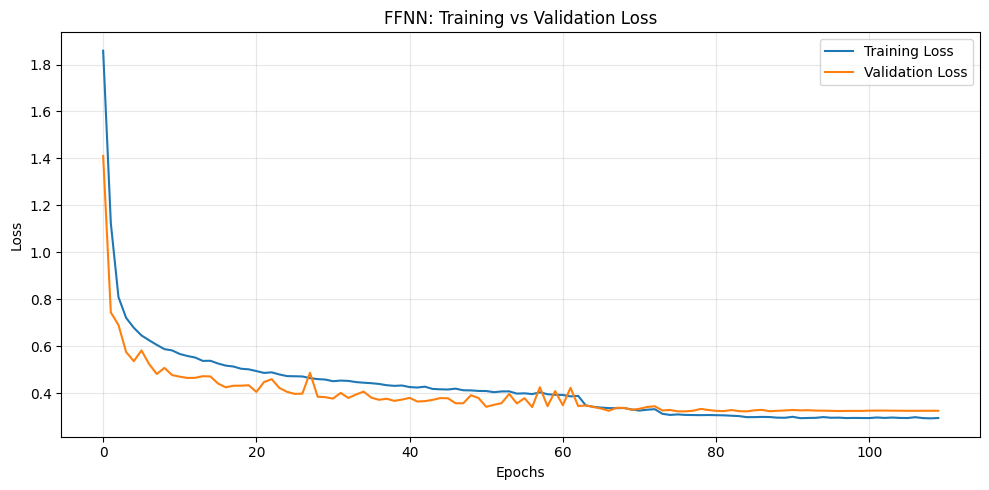

In [13]:
# ffnn_model, t_losses, v_losses = train_model(
#     model=ffnn_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     num_epochs=FFNN_HP["num_epochs"],
#     patience=FFNN_HP["patience"],
#     learning_rate=FFNN_HP["learning_rate"],
#     weight_decay=FFNN_HP["weight_decay"],
#     scheduler_patience=FFNN_HP["scheduler_patience"],
#     scheduler_factor=FFNN_HP["scheduler_factor"],
#     class_weights=class_weights_array,
#     device=DEVICE,
#     save_name="best_ffnn.pkl",
#     model_type="tab_transformer",
# )

# plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")

ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ffnn.pkl",
    model_type="standard",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")


  FFNN Test Set Evaluation
  Accuracy          : 0.9237
  Balanced Accuracy : 0.8889
  F1 (weighted)     : 0.9238
  F1 (macro)        : 0.8841

              precision    recall  f1-score   support

     Grade A       0.94      0.97      0.96      2654
     Grade B       0.96      0.93      0.94      3774
     Grade C       0.95      0.95      0.95      3708
     Grade D       0.94      0.92      0.93      2126
     Grade E       0.88      0.87      0.87      1208
     Grade F       0.76      0.71      0.74       753
     Grade G       0.74      0.86      0.80       608

    accuracy                           0.92     14831
   macro avg       0.88      0.89      0.88     14831
weighted avg       0.92      0.92      0.92     14831



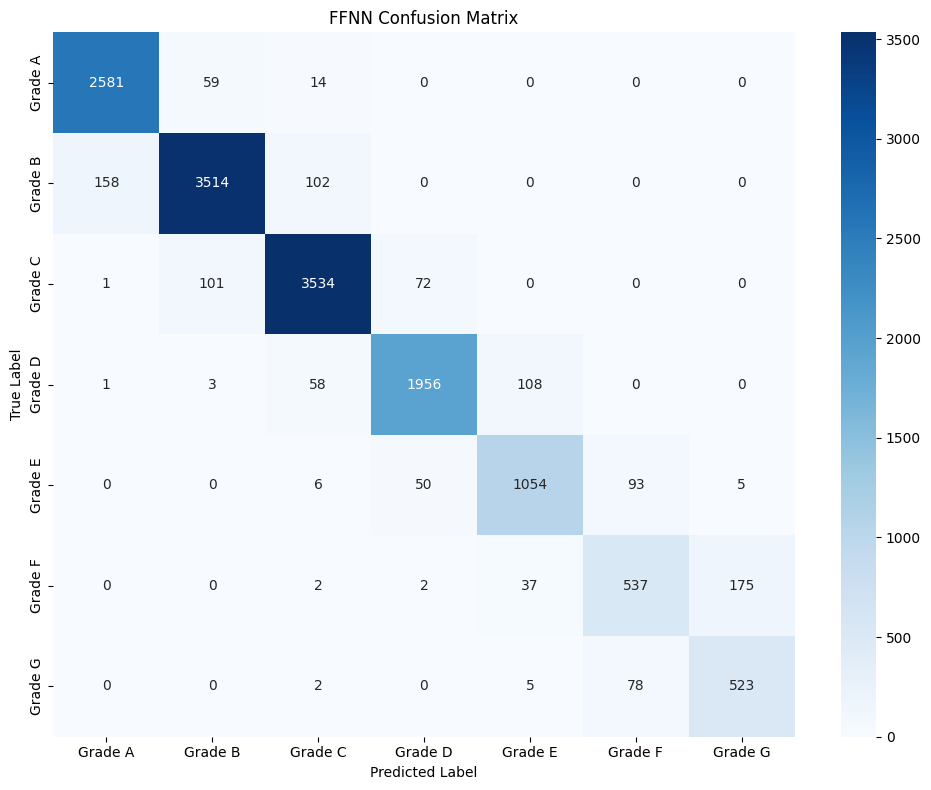

In [14]:
# # Evaluate FFNN
# ffnn_results = evaluate_model(
#     ffnn_model, test_loader, DEVICE,
#     class_names=class_names, model_type="tab_transformer", set_name="FFNN Test"
# )
# plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
#                       class_names=class_names, title="FFNN Confusion Matrix")



# Evaluate FFNN
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="standard", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")



In [ ]:
plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [ ]:
tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
tabnet_model.save_model(tabnet_save_path)
print(f"TabNet model saved to {tabnet_save_path}")

In [ ]:
save_model(tabnet_model, "best_tabnet")

### 3.3 Tab Transformer

In [15]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=8,
    depth=2,
    heads=4,
    attn_dropout=0.3,
    ff_dropout=0.3,
    mlp_hidden_mults=(4, 2),
    # Training
    num_epochs=100,
    batch_size=1024,
    learning_rate=3e-4,
    weight_decay=1e-3,
    patience=20,
    #scheduler_patience=7,
    #scheduler_factor=0.5,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=10,
)

In [16]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data["num_num_cols"]

train_ds_tt = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
val_ds_tt   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
test_ds_tt  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

Numeric: 113, Categorical: 13


In [17]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(dl_data["cat_cardinalities"]),
    num_continuous=dl_data["num_num_cols"],
    cont_mean_std=dl_data["cont_mean_std"],
    num_classes=dl_data["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

TabTransformer(
  (categorical_embeds): Embed(
    (embeddings): Embedding(997, 7)
    (selectors): ModuleList(
      (0): DiscreteContinuousSelector(
        (discrete_selector): DiscreteSelector(
          (embeddings): Embedding(997, 7)
        )
      )
    )
  )
  (norm): LayerNorm((113,), eps=1e-05, elementwise_affine=True)
  (special_token_embed): Embedding(2, 7)
  (transformer): Transformer(
    (layers): ModuleList(
      (0-1): 2 x ModuleList(
        (0): HyperConnections(
          (branch): PreNorm(
            (norm): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
            (fn): Attention(
              (to_qkv): Linear(in_features=8, out_features=192, bias=False)
              (to_out): Linear(in_features=64, out_features=8, bias=True)
              (dropout): Dropout(p=0.3, inplace=False)
            )
          )
          (act): Tanh()
          (split_fracs): Rearrange('b ... (f d) -> b ... f d', f=1)
          (merge_fracs): Rearrange('b ... f d -> b ... (f 

In [ ]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_tab_transformer.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")

Epoch   1/100 | Train 1.9474 | Val 1.9357 | LR 3.27e-05 | ★ best
Epoch   2/100 | Train 1.7312 | Val 1.5035 | LR 6.24e-05 | ★ best
Epoch   3/100 | Train 1.3340 | Val 1.2519 | LR 9.21e-05 | ★ best
Epoch   4/100 | Train 1.1388 | Val 1.0866 | LR 1.22e-04 | ★ best
Epoch   5/100 | Train 0.9878 | Val 0.9357 | LR 1.51e-04 | ★ best
Epoch   6/100 | Train 0.8618 | Val 0.8268 | LR 1.81e-04 | ★ best
Epoch   7/100 | Train 0.7681 | Val 0.7489 | LR 2.11e-04 | ★ best
Epoch   8/100 | Train 0.7033 | Val 0.7037 | LR 2.41e-04 | ★ best
Epoch   9/100 | Train 0.6609 | Val 0.8309 | LR 2.70e-04 | no improve 1/20
Epoch  10/100 | Train 0.6358 | Val 0.6400 | LR 3.00e-04 | ★ best
Epoch  11/100 | Train 0.6088 | Val 0.6257 | LR 3.00e-04 | ★ best
Epoch  12/100 | Train 0.5825 | Val 0.6318 | LR 3.00e-04 | no improve 1/20
Epoch  13/100 | Train 0.5581 | Val 0.5889 | LR 2.99e-04 | ★ best
Epoch  14/100 | Train 0.5393 | Val 0.6153 | LR 2.99e-04 | no improve 1/20
Epoch  15/100 | Train 0.5223 | Val 0.5733 | LR 2.98e-04 | ★ bes

In [ ]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

### 3.4 FT-Transformer (attention over ALL features)

Unlike TabTransformer (which only applies attention to categorical features),
FTTransformer tokenizes **all** features — numerical and categorical — into
embeddings, then runs self-attention over the full set. This is better suited
for datasets with many numerical features (105 numerical vs 13 categorical here).

In [ ]:
# ── FTTransformer Hyperparameters (edit here) ──
FT_HP = dict(
    # Architecture
    dim=64,
    depth=4,
    heads=8,
    attn_dropout=0.2,
    ff_dropout=0.2,
    # Training
    num_epochs=100,
    batch_size=512,
    learning_rate=1e-4,
    weight_decay=1e-3,
    patience=25,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=5,
)

In [ ]:
# Build datasets (same TabularDataset as TabTransformer)
n_num = dl_data["num_num_cols"]

train_ds_ft = TabularDataset(dl_data["X_train"], dl_data["y_train"], n_num)
val_ds_ft   = TabularDataset(dl_data["X_val"],   dl_data["y_val"],   n_num)
test_ds_ft  = TabularDataset(dl_data["X_test"],  dl_data["y_test"],  n_num)

train_loader_ft, val_loader_ft, test_loader_ft = create_loaders(
    train_ds_ft, val_ds_ft, test_ds_ft, batch_size=FT_HP["batch_size"]
)

print(f"Numeric: {train_ds_ft.n_num}, Categorical: {train_ds_ft.n_cat}")

In [ ]:
# Build FTTransformer
fix_random(SEED)

ft_transformer = build_ft_transformer(
    cat_cardinalities=tuple(dl_data["cat_cardinalities"]),
    num_continuous=dl_data["num_num_cols"],
    num_classes=dl_data["num_classes"],
    dim=FT_HP["dim"],
    depth=FT_HP["depth"],
    heads=FT_HP["heads"],
    attn_dropout=FT_HP["attn_dropout"],
    ff_dropout=FT_HP["ff_dropout"],
    device=DEVICE,
)

print(ft_transformer)
print(f"Parameters: {sum(p.numel() for p in ft_transformer.parameters()):,}")

In [ ]:
# Train FTTransformer
ft_transformer, t_losses_ft, v_losses_ft = train_model(
    model=ft_transformer,
    train_loader=train_loader_ft,
    val_loader=val_loader_ft,
    num_epochs=FT_HP["num_epochs"],
    patience=FT_HP["patience"],
    learning_rate=FT_HP["learning_rate"],
    weight_decay=FT_HP["weight_decay"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="best_ft_transformer.pkl",
    model_type="tab_transformer",  # same forward interface: model(x_cat, x_num)
    max_grad_norm=FT_HP.get("max_grad_norm"),
    use_cosine_scheduler=FT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=FT_HP.get("warmup_epochs", 0),
)

plot_losses(t_losses_ft, v_losses_ft, title="FTTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate FTTransformer
ft_results = evaluate_model(
    ft_transformer, test_loader_ft, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="FTTransformer Test"
)
plot_confusion_matrix(ft_results["y_true"], ft_results["y_pred"],
                      class_names=class_names, title="FTTransformer Confusion Matrix")

## 4. Results Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models (CV results)
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models (test set)
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")